CNN has performed better performance we cann see we have have got : 92 % of the accuracy on the test set and in train set we got the 99 % . In ANN we have to optimize a lot with tuning to get this type of accuracy . So CNN performs so better on the image type of the data. 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
# check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"using device {device}")

using device cuda


In [4]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


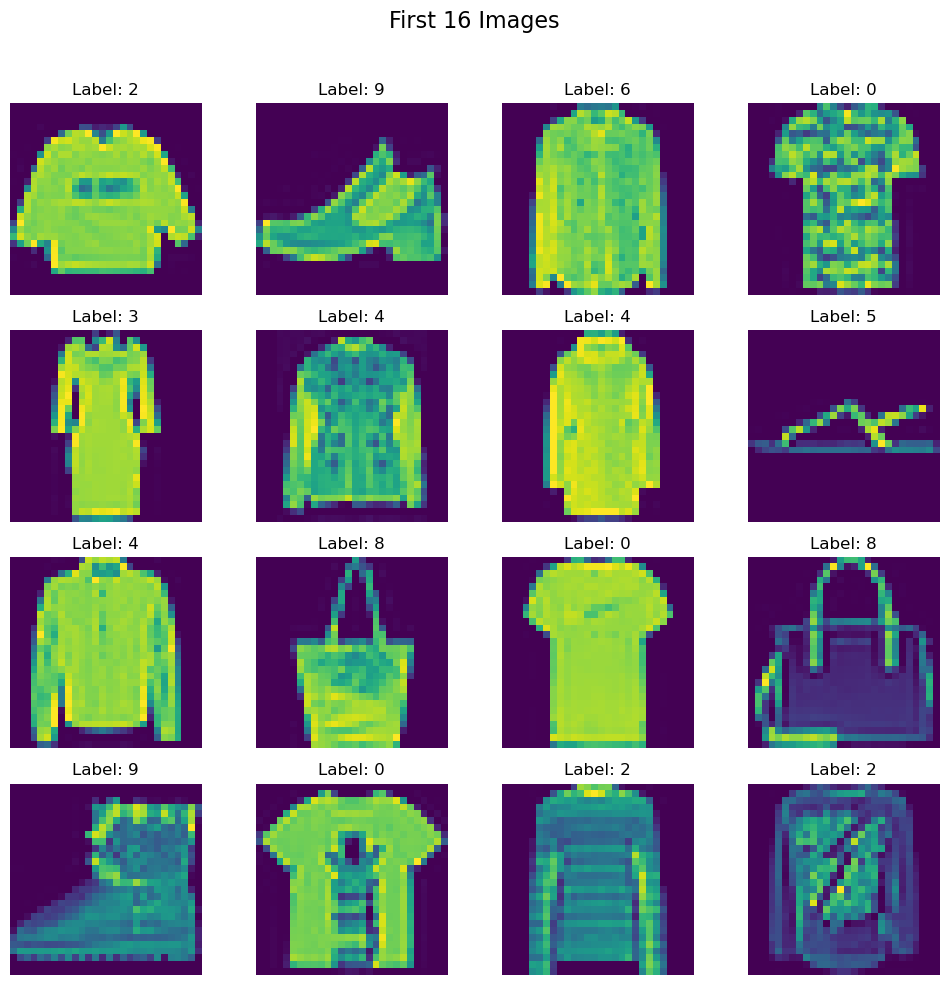

In [5]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [6]:
# train test split

X= df.iloc[:,1:].values
y= df.iloc[:,0].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]], shape=(48000, 784))

In [ ]:
#create CustomeDataset class

class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)  # -1 is the placeholder for the batch size, and 1 is for the channel no. and 28, 28 is the size of image
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [11]:
#create train_dataset object 

train_dataset=CustomDataset(X_train,y_train)


In [12]:
# create  test_dataset object 

test_dataset = CustomDataset(X_test,y_test)

In [13]:
# create train and test loader 

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True , pin_memory=True) # this pin_memory is for speed on gpu. It store data in pin memory instread of first page memory to gpu memory

test_loader = DataLoader(test_dataset,batch_size=32, shuffle=False, pin_memory=True)

In [14]:
# define CNN class

class FashionCNN(nn.Module):

    def __init__(self,input_features):

        super().__init__()

        self.features = nn.Sequential(
            #first convulational layers
            nn.Conv2d(input_features,32,kernel_size=3 , padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Second convulational layers

            nn.Conv2d(32,64,kernel_size=3 , padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier  = nn.Sequential(
            # first classification hidden layer
            nn.Flatten(),
            nn.Linear(64*7*7 , 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),

# second classification hidden layer
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.4),


# final layer
            nn.Linear(64,10)
        )

    def forward(self,X):
        X= self.features(X)
        X= self.classifier(X)
        return X


In [15]:
# set learning rate and epochs 

epochs = 100
learning_rate = 0.1 


In [16]:
# instantiate the model 

model = FashionCNN(1)

# move model to device ie gpu
model.to(device)

# loss function

criterion = nn.CrossEntropyLoss()

# optimizer 
optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)


In [ ]:
len(train_loader)

In [17]:
# training loop 

for epoch in range(epochs):

    total_epoch_loss = 0
    for batch_features,batch_labels in train_loader:

        # Move data to gpu

        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)
        # calculate loss

        loss = criterion(outputs,batch_labels)

        #clear gradients
        optimizer.zero_grad()

        # back pass
        loss.backward()

        # update gradients 
        optimizer.step()

        total_epoch_loss += loss.item() 


    print(f"Epoch: {epoch +1 } ,AVG_loss :: {total_epoch_loss/len(train_loader)}")

Epoch: 1 ,AVG_loss :: 0.5909974411378304
Epoch: 2 ,AVG_loss :: 0.4156409799456596
Epoch: 3 ,AVG_loss :: 0.3504324671278397
Epoch: 4 ,AVG_loss :: 0.31401322935024895
Epoch: 5 ,AVG_loss :: 0.2850492177382112
Epoch: 6 ,AVG_loss :: 0.26124796611443163
Epoch: 7 ,AVG_loss :: 0.2448235808337728
Epoch: 8 ,AVG_loss :: 0.22691344429490468
Epoch: 9 ,AVG_loss :: 0.22105075665811696
Epoch: 10 ,AVG_loss :: 0.20884727757858734
Epoch: 11 ,AVG_loss :: 0.19708758062900356
Epoch: 12 ,AVG_loss :: 0.18787978042041262
Epoch: 13 ,AVG_loss :: 0.18455045936256648
Epoch: 14 ,AVG_loss :: 0.1777937525593055
Epoch: 15 ,AVG_loss :: 0.17166675447144855
Epoch: 16 ,AVG_loss :: 0.1617285041830813
Epoch: 17 ,AVG_loss :: 0.15641172667623807
Epoch: 18 ,AVG_loss :: 0.1513025900986977
Epoch: 19 ,AVG_loss :: 0.14497081763716416
Epoch: 20 ,AVG_loss :: 0.14540655496460386
Epoch: 21 ,AVG_loss :: 0.13705299958835046
Epoch: 22 ,AVG_loss :: 0.1368608207688667
Epoch: 23 ,AVG_loss :: 0.13685708783334122
Epoch: 24 ,AVG_loss :: 0.1230

In [18]:
# set model to eval mode 

model.eval()

# this triggers the model to evaluation mode . It is useful when we use the dropouts, batch normalizations etc. 



FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
len(test_loader)

375

In [20]:
# evaluation code 

total = 0

correct = 0

with torch.no_grad():

    for batch_features,batch_labels in test_loader:
        # there are 32 batches in test loader

        # Move data to gpu
        
        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        # here on trained model we are sending 1 batch of the data ie 32 images . so model will give us the output for each image out of 10 values which are probability of being 1 to 10 ). 
        # So tensor (32,10) will be given so for each row the maximum value(ie hihg prob) will decide which label will be predictions 

        _, predicted = torch.max(outputs,1) 

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

    print(correct/total)




0.91875


In [21]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9929583333333334


In [22]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

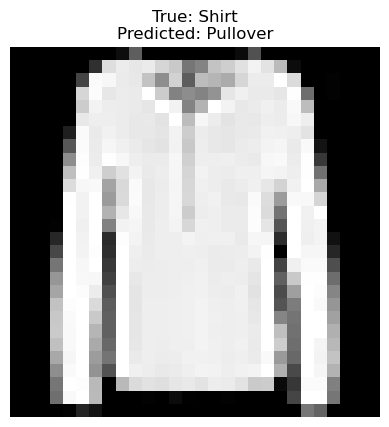

In [23]:
import random

# Random sample index
idx = random.randint(0, len(test_dataset)-1)

# Get image and label
image, true_label = test_dataset[idx]

# Add batch dimension
image_batch = image.unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(image_batch)
    _, predicted = torch.max(outputs, 1)

predicted_label = predicted.item()

# Display image
plt.imshow(image.view(28,28), cmap='gray')
plt.title(
    f"True: {classes[true_label]}\n"
    f"Predicted: {classes[predicted_label]}"
)
plt.axis("off")
plt.show()

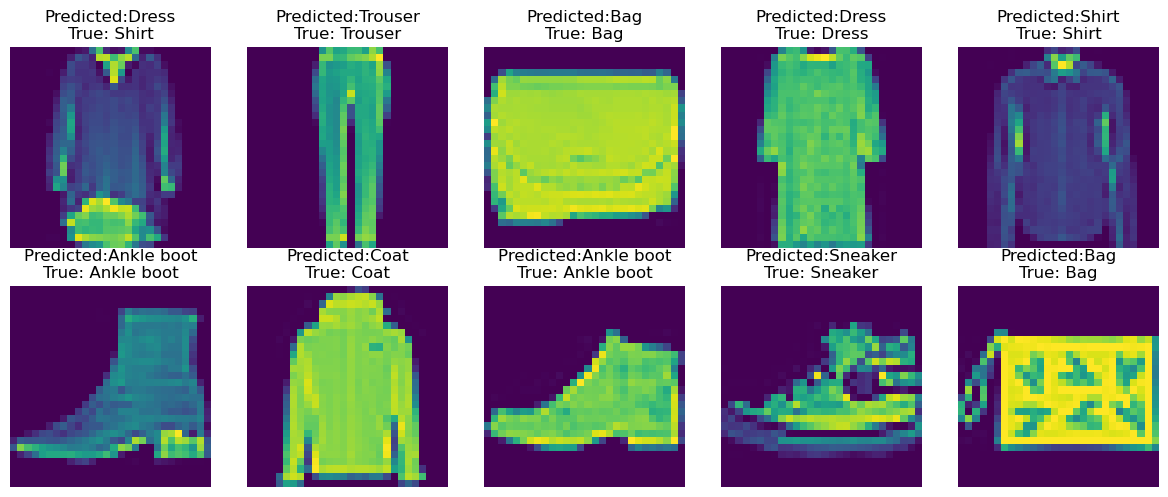

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

model.eval()

for ax in axes.flat:

    idx = random.randint(0, len(test_dataset)-1)

    image, label = test_dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()

    ax.imshow(image.view(28,28))
    ax.set_title(
        f"Predicted:{classes[pred]}\n"
        f"True: {classes[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()